In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\ADITYA GUPTA\Downloads\Data\Quick_commerce_data.csv")
df.head(5)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [3]:
df.shape

(1000000, 13)

In [4]:
df.columns

Index(['Order_ID', 'Company', 'City', 'Customer_Age', 'Order_Value',
       'Delivery_Time_Min', 'Distance_Km', 'Items_Count', 'Product_Category',
       'Payment_Method', 'Customer_Rating', 'Discount_Applied',
       'Delivery_Partner_Rating'],
      dtype='str')

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [7]:
df = df.replace(" ", np.nan)
df.isnull().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [8]:
df = df.dropna()
df.isnull().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

In [9]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,7.809920e+05,780992.000000,780992.000000,780992.000000,780992.000000,780992.000000,780992.000000,780992.000000,780992.000000
mean,1.499959e+06,38.466559,572.071012,16.503102,7.749609,10.002955,3.042958,0.401075,3.749185
std,2.886968e+05,12.124426,382.029034,6.330765,4.188874,5.478477,1.187670,0.490116,0.722051
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.249855e+06,28.000000,287.744550,12.362000,4.120000,5.000000,2.000000,0.000000,3.100000
50%,1.499894e+06,38.000000,531.819125,16.384000,7.750000,10.000000,3.000000,0.000000,3.700000
75%,1.750007e+06,49.000000,796.993350,20.304000,11.380000,15.000000,4.000000,1.000000,4.400000
max,2.000000e+06,59.000000,13405.628250,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [10]:
df[['Company']]

,Company
0,Swiggy Instamart
1,Flipkart Minutes
3,Swiggy Instamart
4,Dunzo
5,Jio Mart
...,...
999995,Big Basket
999996,Swiggy Instamart
999997,Jio Mart
999998,Dunzo


# Feature Engineering

In [11]:
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2


In [12]:
#Average Delivery Time
df['Delivery_Speed'] = df['Distance_Km'] / df['Delivery_Time_Min']
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Speed
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2,0.624023
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2,0.648544


In [13]:
#Revenue per Item
df['Revenue'] = df['Order_Value'] / df['Items_Count']
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Speed,Revenue
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2,0.624023,58.528125
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2,0.648544,100.730000


In [14]:
# 3. Age Group
df['Age_Group'] = pd.cut(df['Customer_Age'], 
                   bins=[0,25,35,50,100], 
                   labels=['Youth','Young Adult','Adult','Senior'])
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Speed,Revenue,Age_Group
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2,0.624023,58.528125,Adult
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2,0.648544,100.730000,Senior


In [15]:
df['Delivery_Tag'] = pd.cut(df['Delivery_Time_Min'],
                     bins=[0,30,60,120],
                     labels=['Fast','Moderate','Slow'])
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Speed,Revenue,Age_Group,Delivery_Tag
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2,0.624023,58.528125,Adult,Fast
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2,0.648544,100.730000,Senior,Fast


In [16]:
df['Is_High_Value'] = df['Order_Value'] > df['Order_Value'].quantile(0.75)
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Speed,Revenue,Age_Group,Delivery_Tag,Is_High_Value
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2,0.624023,58.528125,Adult,Fast,False
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2,0.648544,100.730000,Senior,Fast,True


In [17]:
df['Is_Happy_Customer'] = df['Customer_Rating'] >= 4
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Speed,Revenue,Age_Group,Delivery_Tag,Is_High_Value,Is_Happy_Customer
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2,0.624023,58.528125,Adult,Fast,False,False
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2,0.648544,100.730000,Senior,Fast,True,False


# KPIs / Measures

In [18]:
df.head(2)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Speed,Revenue,Age_Group,Delivery_Tag,Is_High_Value,Is_Happy_Customer
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2,0.624023,58.528125,Adult,Fast,False,False
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2,0.648544,100.730000,Senior,Fast,True,False


In [19]:
#Average Delivery Time
df['Delivery_Time_Min'].mean()

np.float64(16.503101875563384)

In [20]:
#Average Order Value
df['Order_Value'].mean()

np.float64(572.0710124543529)

In [21]:
#Percentage of orders with a rating of 4 or higher
total = df.shape[0]
df[df['Customer_Rating'] >= 4].shape[0] / total * 100

27.43690076210768

In [22]:
#Distribution of Customer Ratings
df['Discount_Applied'].value_counts(normalize=True)

Discount_Applied
0    0.598925
1    0.401075
Name: proportion, dtype: float64

In [23]:
#Average Distance
df['Distance_Km'].mean()

np.float64(7.749608792407605)

In [24]:
#Average Delivery Partner Rating
df['Delivery_Partner_Rating'].mean()

np.float64(3.749185266942555)

In [25]:
df['Age_Group'].value_counts(normalize=True) * 100

Age_Group
Adult          35.630583
Young Adult    23.860040
Senior         21.402780
Youth          19.106598
Name: proportion, dtype: float64

#  Visualizations

#Top 5 Insights to Write in Conclusion
#Which Company has best rating & fastest delivery
#Which City generates most revenue
#Does Discount actually improve customer rating?
#Which Age Group orders the most/highest value

In [26]:
df.head(3)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Speed,Revenue,Age_Group,Delivery_Tag,Is_High_Value,Is_Happy_Customer
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2,0.624023,58.528125,Adult,Fast,False,False
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2,0.648544,100.730000,Senior,Fast,True,False
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0,1.098226,589.529625,Youth,Fast,True,True


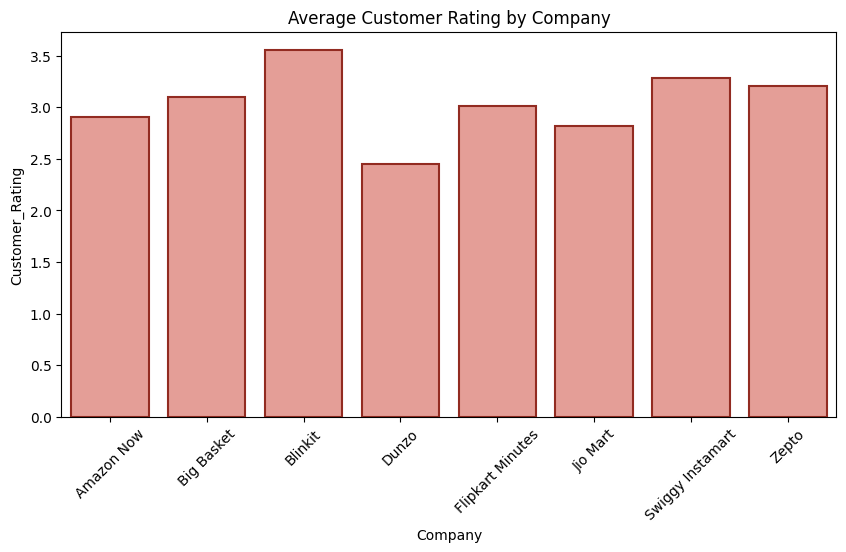

In [27]:
#Average Customer Rating by Company
company_stats = df.groupby('Company').agg({
    'Customer_Rating': 'mean',
    'Delivery_Time_Min': 'mean'
}).reset_index()

plt.figure(figsize=(10, 5))

sns.barplot(
    data=company_stats,
    x='Company',
    y='Customer_Rating',
    color='#F1948A',
    edgecolor='#922B21',
    linewidth=1.5
)

plt.title("Average Customer Rating by Company")
plt.xticks(rotation=45)
plt.show()

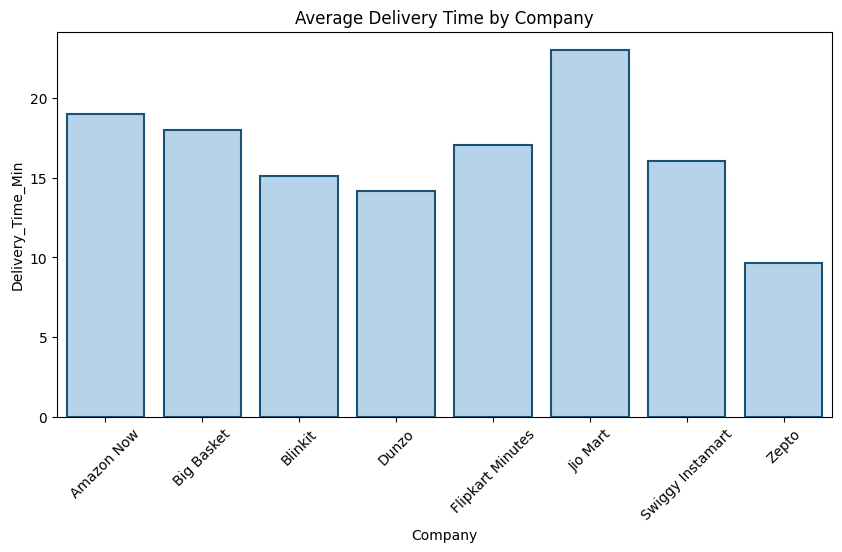

In [28]:
#Average Delivery Time by Company
plt.figure(figsize=(10,5))

sns.barplot(
    data=company_stats,
    x='Company',
    y='Delivery_Time_Min',
    color='#AED6F1',
    edgecolor='#1A5276',
    linewidth=1.5
)

plt.title("Average Delivery Time by Company")
plt.xticks(rotation=45)
plt.show()

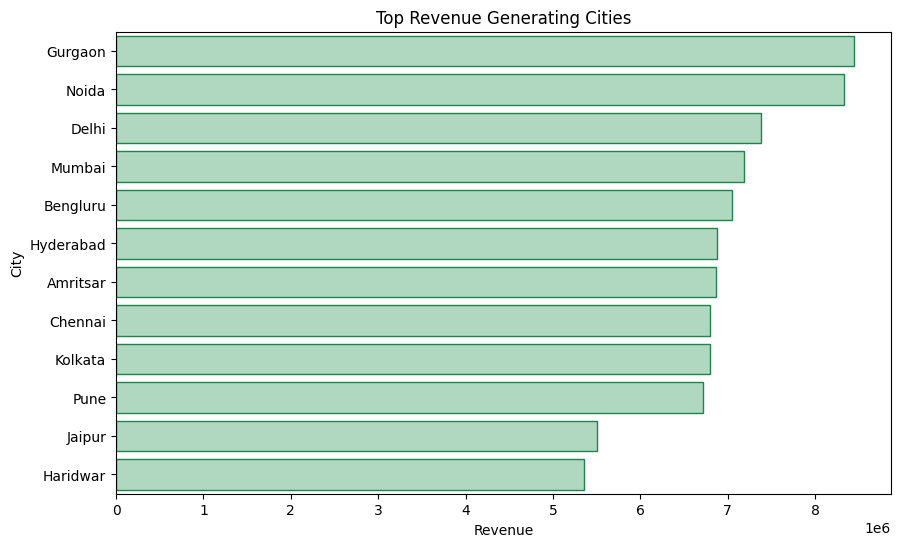

In [29]:
#Revenue by City
city_revenue = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=city_revenue.values,
    y=city_revenue.index,
    color='#A9DFBF',
    edgecolor='#1E8449'
)

plt.title("Top Revenue Generating Cities")
plt.xlabel("Revenue")
plt.ylabel("City")

plt.show()

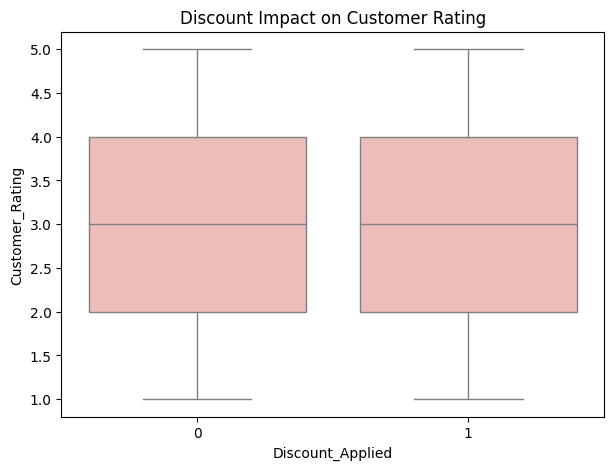

In [30]:
#Discount Impact on Customer Rating
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Discount_Applied',
    y='Customer_Rating',
    color='#F5B7B1',
)

plt.title("Discount Impact on Customer Rating")

plt.show()

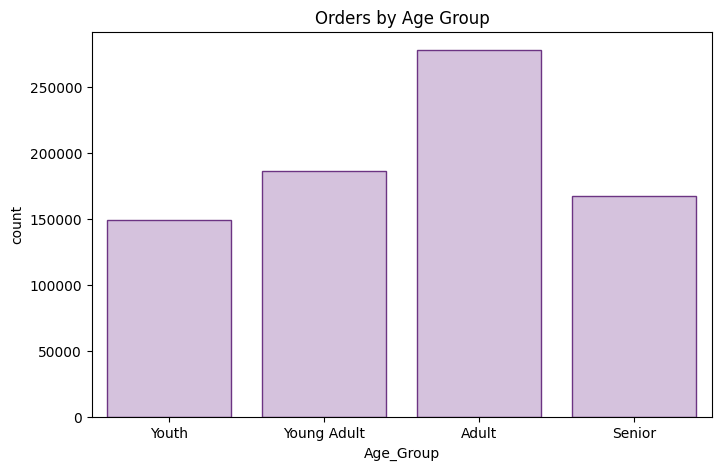

In [31]:
#Orders by Age Group
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Age_Group',
    color='#D7BDE2',
    edgecolor='#6C3483'
)

plt.title("Orders by Age Group")

plt.show()

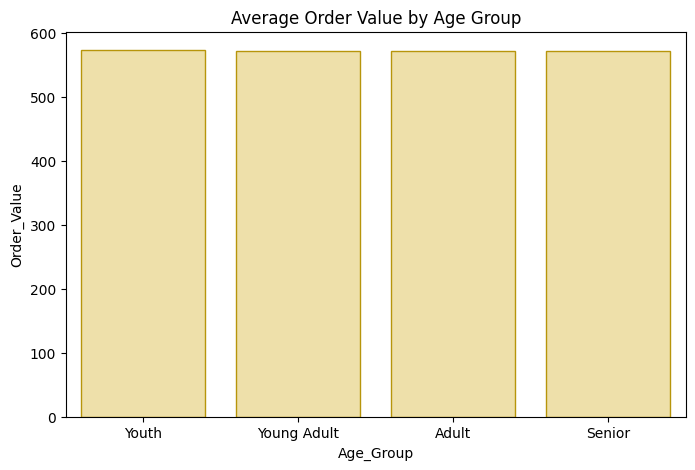

In [32]:
#Average Order Value by Age Group
age_value = df.groupby('Age_Group')['Order_Value'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=age_value,
    x='Age_Group',
    y='Order_Value',
    color='#F9E79F',
    edgecolor='#B7950B'
)

plt.title("Average Order Value by Age Group")

plt.show()